<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-5/blob/main/a.%20ensemble_vs_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos Ensemble vs Modelo Individual
## Comparación de Eficiencia en Clasificación

En este notebook vamos a:
1. Preparar y explorar un dataset de clasificación
2. Entrenar un **modelo individual** (Árbol de Decisión)
3. Entrenar tres **modelos ensemble** (Bagging, Random Forest, Gradient Boosting)
4. Comparar métricas y determinar cuál es el mejor


## 1. Instalación e Importación de Librerías

In [2]:
# Instalación (por si acaso)
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Dataset y preprocesamiento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Sklearn - Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Sklearn - Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga y Exploración del Dataset

Usamos el dataset **Breast Cancer Wisconsin** (incluido en scikit-learn):
- **569 muestras**, **30 características** numéricas
- **Tarea**: clasificar tumores como Benignos (0) o Malignos (1)


In [4]:
# Cargar dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('=' * 50)
print(f'Forma del dataset: {X.shape}')
print(f'Clases: {data.target_names}')
print(f'Distribución de clases:\n{y.value_counts().rename(index={0: "Maligno", 1: "Benigno"})}')
print('=' * 50)

X.head(3)

Forma del dataset: (569, 30)
Clases: ['malignant' 'benign']
Distribución de clases:
target
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


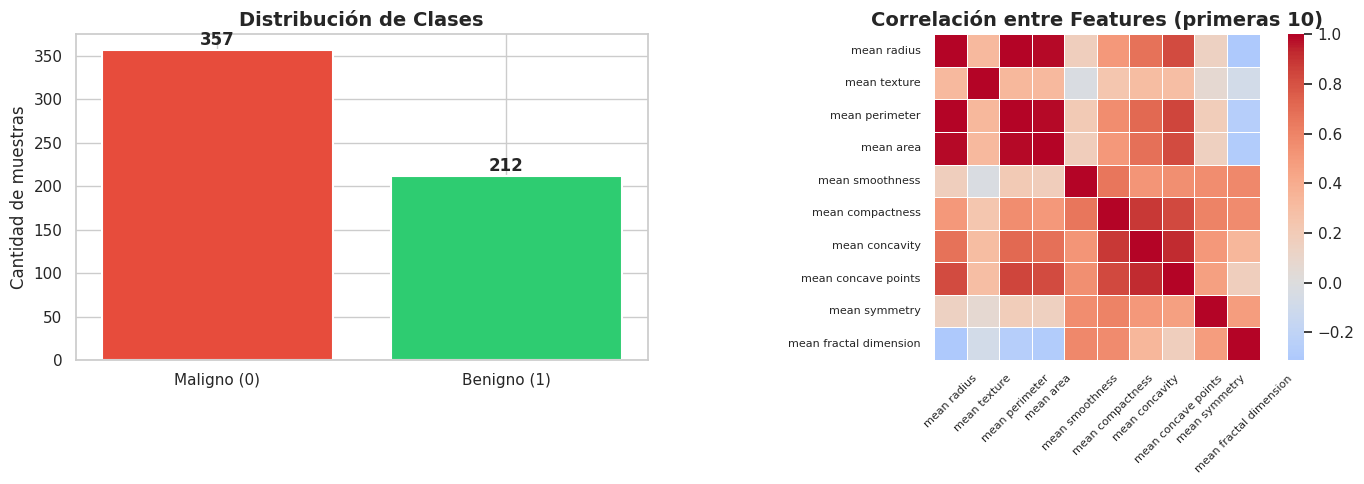

In [5]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
counts = y.value_counts()
axes[0].bar(['Maligno (0)', 'Benigno (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Clases', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Cantidad de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Correlación de las 10 primeras features
corr = X.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[1], annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
axes[1].set_title('Correlación entre Features (primeras 10)', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

##  3. División y Preprocesamiento de Datos

In [7]:
# División 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # Mantiene proporción de clases
)

# Escalado (necesario para algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'📚 Entrenamiento : {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'🧪 Prueba         : {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')

📚 Entrenamiento : 455 muestras (80%)
🧪 Prueba         : 114 muestras (20%)


## 4. Modelo Individual — Árbol de Decisión

Modelo base de referencia. Aprende reglas de decisión directamente de los datos, pero es propenso al **overfitting**.


In [9]:
# Entrenar Árbol de Decisión
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('ÁRBOL DE DECISIÓN — Reporte de Clasificación')
print('=' * 55)
print(classification_report(y_test, y_pred_dt,
                             target_names=['Maligno', 'Benigno']))

ÁRBOL DE DECISIÓN — Reporte de Clasificación
              precision    recall  f1-score   support

     Maligno       0.87      0.93      0.90        42
     Benigno       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



## 5. Modelos Ensemble

Los modelos ensemble combinan múltiples modelos para mejorar la predicción:

| Modelo | Técnica | Idea clave |
|--------|---------|------------|
| **Bagging** | Bootstrap + promedio | Reduce varianza |
| **Random Forest** | Bagging + subconjunto de features | Reduce varianza + decorrelación |
| **Gradient Boosting** | Suma de modelos débiles (boosting) | Reduce sesgo |


In [10]:
# ── Bagging Classifier ──────────────────────────────────
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print('BAGGING — Reporte de Clasificación')
print('=' * 55)
print(classification_report(y_test, y_pred_bag,
                             target_names=['Maligno', 'Benigno']))

BAGGING — Reporte de Clasificación
              precision    recall  f1-score   support

     Maligno       0.95      0.93      0.94        42
     Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
# ── Random Forest ────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('🌲 RANDOM FOREST — Reporte de Clasificación')
print('=' * 55)
print(classification_report(y_test, y_pred_rf,
                             target_names=['Maligno', 'Benigno']))

🌲 RANDOM FOREST — Reporte de Clasificación
              precision    recall  f1-score   support

     Maligno       0.95      0.93      0.94        42
     Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [13]:
# ── Gradient Boosting ────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('GRADIENT BOOSTING — Reporte de Clasificación')
print('=' * 55)
print(classification_report(y_test, y_pred_gb,
                             target_names=['Maligno', 'Benigno']))

GRADIENT BOOSTING — Reporte de Clasificación
              precision    recall  f1-score   support

     Maligno       0.97      0.90      0.94        42
     Benigno       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 6. Tabla Comparativa de Métricas

In [15]:
# Función para calcular todas las métricas
def get_metrics(name, y_true, y_pred, model, X_test_data):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, model.predict_proba(X_test_data)[:, 1]),
        'CV Accuracy (mean)': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

# Calcular métricas para cada modelo
results = [
    get_metrics('Árbol Decisión',    y_test, y_pred_dt,  dt,      X_test),
    get_metrics('Bagging',           y_test, y_pred_bag, bagging, X_test),
    get_metrics('Random Forest',     y_test, y_pred_rf,  rf,      X_test),
    get_metrics('Gradient Boosting', y_test, y_pred_gb,  gb,      X_test),
]

df_results = pd.DataFrame(results).set_index('Modelo')

# Formatear
df_display = df_results.copy()
for col in df_display.columns:
    df_display[col] = df_display[col].map(lambda x: f'{x:.4f}')

print('\nTABLA COMPARATIVA DE MÉTRICAS')
print('=' * 80)
print(df_display.to_string())
print('=' * 80)


TABLA COMPARATIVA DE MÉTRICAS
                  Accuracy Precision  Recall F1-Score ROC-AUC CV Accuracy (mean)  CV Std
Modelo                                                                                  
Árbol Decisión      0.9211    0.9565  0.9167   0.9362  0.9163             0.9280  0.0230
Bagging             0.9561    0.9589  0.9722   0.9655  0.9929             0.9561  0.0156
Random Forest       0.9561    0.9589  0.9722   0.9655  0.9931             0.9543  0.0102
Gradient Boosting   0.9561    0.9467  0.9861   0.9660  0.9917             0.9543  0.0170


## 7. Visualización Comparativa

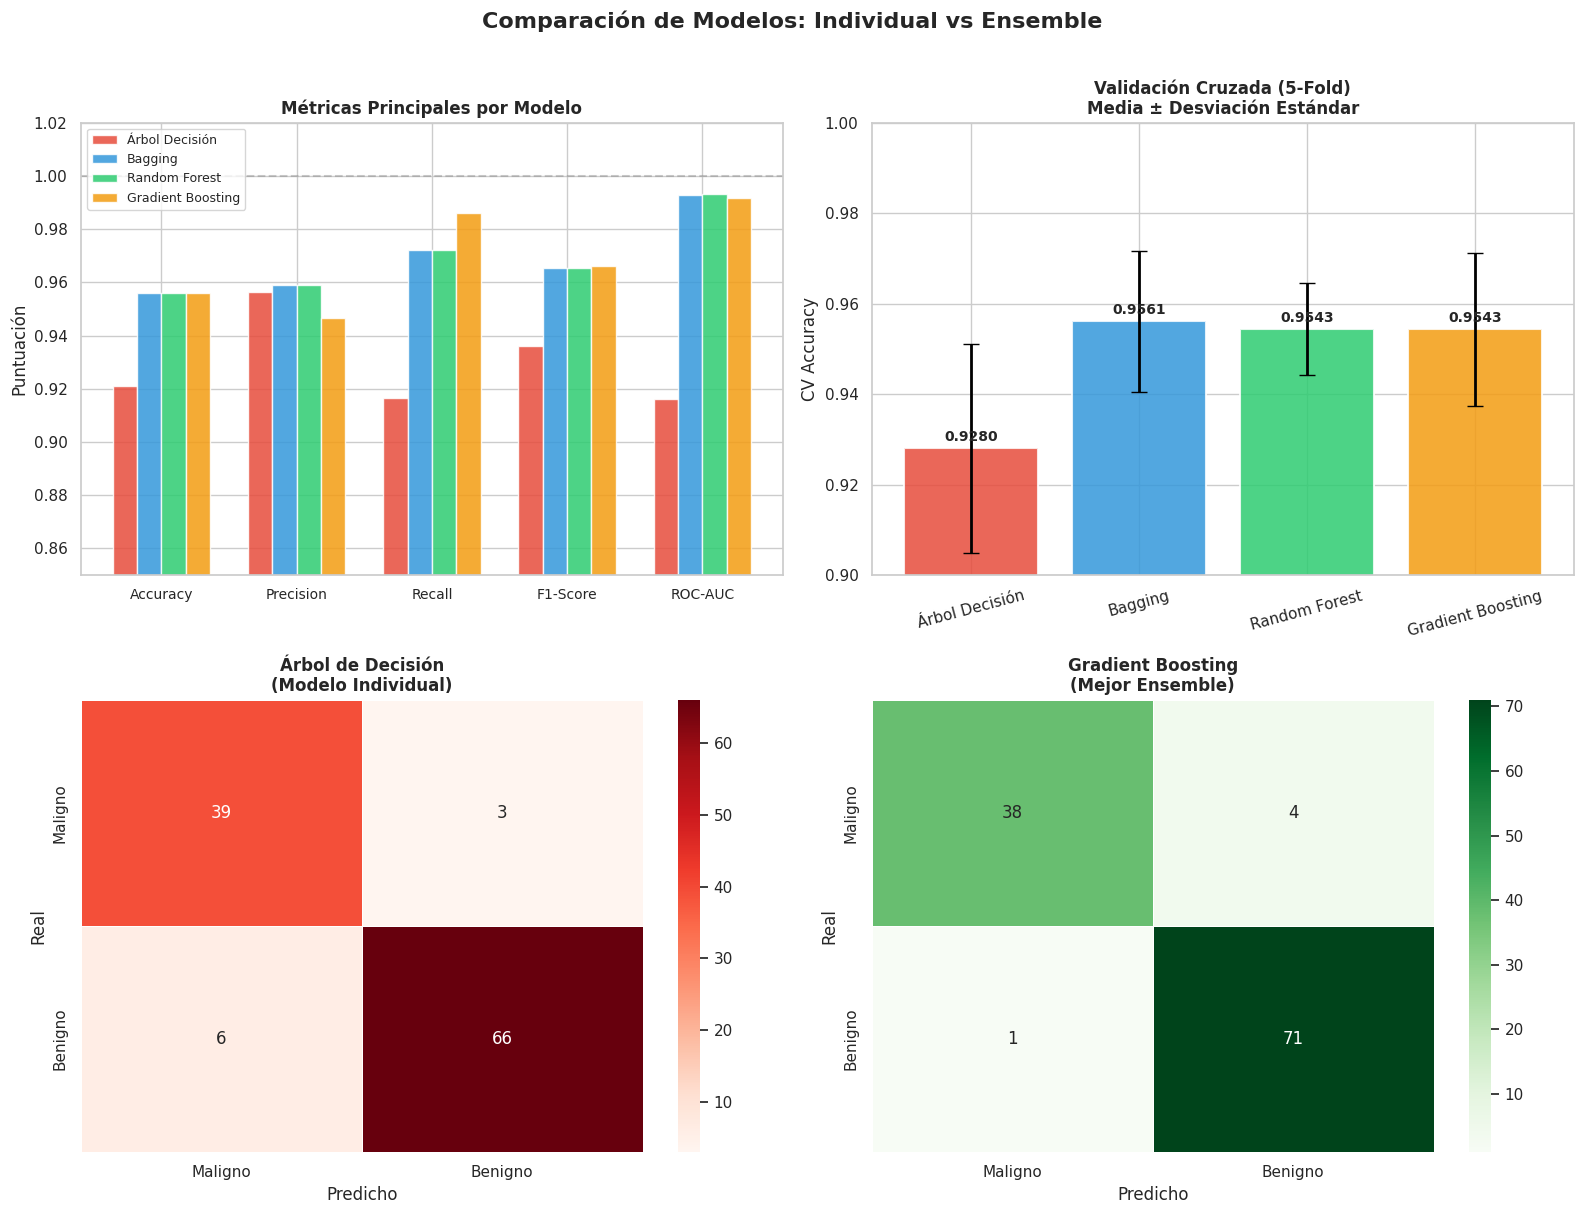

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación de Modelos: Individual vs Ensemble',
             fontsize=16, fontweight='bold', y=1.01)

colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
nombres = df_results.index

# ── Gráfico 1: Barras de métricas principales
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metricas))
width = 0.18
for i, (idx, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metricas]
    bars = axes[0, 0].bar(x + i*width, vals, width, label=nombres[i],
                          color=colores[i], alpha=0.85, edgecolor='white')
axes[0, 0].set_xticks(x + width*1.5)
axes[0, 0].set_xticklabels(metricas, fontsize=10)
axes[0, 0].set_ylim(0.85, 1.02)
axes[0, 0].set_title('Métricas Principales por Modelo', fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_ylabel('Puntuación')
axes[0, 0].axhline(1.0, color='gray', linestyle='--', alpha=0.4)

# ── Gráfico 2: Validación cruzada (boxplot simulado con media ± std)
cv_means = df_results['CV Accuracy (mean)'].values
cv_stds  = df_results['CV Std'].values
bars = axes[0, 1].bar(nombres, cv_means, color=colores, alpha=0.85,
                       edgecolor='white', linewidth=1.5)
axes[0, 1].errorbar(nombres, cv_means, yerr=cv_stds, fmt='none',
                    color='black', capsize=6, linewidth=2)
axes[0, 1].set_title('Validación Cruzada (5-Fold)\nMedia ± Desviación Estándar', fontweight='bold')
axes[0, 1].set_ylabel('CV Accuracy')
axes[0, 1].set_ylim(0.90, 1.00)
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, cv_means):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Gráfico 3: Matrices de confusión (Random Forest y DT)
# Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0],
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'], linewidths=0.5)
axes[1, 0].set_title('Árbol de Decisión\n(Modelo Individual)', fontweight='bold')
axes[1, 0].set_xlabel('Predicho'); axes[1, 0].set_ylabel('Real')

# Gradient Boosting (mejor ensemble)
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'], linewidths=0.5)
axes[1, 1].set_title('Gradient Boosting\n(Mejor Ensemble)', fontweight='bold')
axes[1, 1].set_xlabel('Predicho'); axes[1, 1].set_ylabel('Real')

plt.tight_layout()
plt.show()

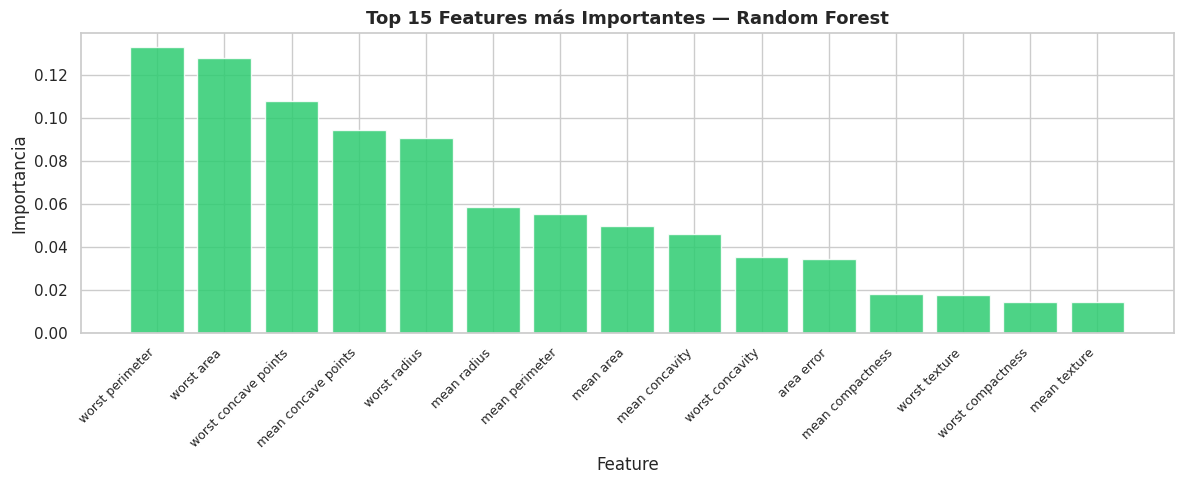

In [18]:
# ── Importancia de Features (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15
feature_names_top = [data.feature_names[i] for i in indices]

plt.figure(figsize=(12, 5))
plt.bar(range(15), importances[indices], color='#2ecc71', alpha=0.85, edgecolor='white')
plt.xticks(range(15), feature_names_top, rotation=45, ha='right', fontsize=9)
plt.title('Top 15 Features más Importantes — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

##  8. Conclusiones y Respuesta Final

In [20]:
# Identificar el mejor modelo por F1-Score
mejor_idx   = df_results['F1-Score'].idxmax()
mejor_f1    = df_results.loc[mejor_idx, 'F1-Score']
mejor_acc   = df_results.loc[mejor_idx, 'Accuracy']
mejor_auc   = df_results.loc[mejor_idx, 'ROC-AUC']
mejor_cv    = df_results.loc[mejor_idx, 'CV Accuracy (mean)']
mejor_std   = df_results.loc[mejor_idx, 'CV Std']

dt_f1 = df_results.loc['Árbol Decisión', 'F1-Score']
mejora = (mejor_f1 - dt_f1) / dt_f1 * 100

print()
print('=' * 65)
print('CONCLUSIONES FINALES')
print('=' * 65)
print()
print(f'MEJOR MODELO: {mejor_idx}')
print(f'   • Accuracy  : {mejor_acc:.4f} ({mejor_acc*100:.2f}%)')
print(f'   • F1-Score  : {mejor_f1:.4f}')
print(f'   • ROC-AUC   : {mejor_auc:.4f}')
print(f'   • CV Accuracy: {mejor_cv:.4f} ± {mejor_std:.4f}')
print()
print(f'COMPARACIÓN vs Árbol de Decisión (modelo individual):')
print(f'   • F1-Score del Árbol : {dt_f1:.4f}')
print(f'   • F1-Score del mejor : {mejor_f1:.4f}')
print(f'   • Mejora relativa    : +{mejora:.2f}%')
print()
print('ANÁLISIS:')
print('   Los modelos ensemble SUPERAN al modelo individual porque:')
print('   1. Reducen el overfitting al promediar múltiples modelos')
print('   2. Tienen menor varianza → más estables en datos nuevos')
print('   3. Gradient Boosting minimiza el sesgo de forma iterativa')
print('   4. Random Forest añade aleatoriedad en features → menos correlación')
print()
print('=' * 65)


CONCLUSIONES FINALES

MEJOR MODELO: Gradient Boosting
   • Accuracy  : 0.9561 (95.61%)
   • F1-Score  : 0.9660
   • ROC-AUC   : 0.9917
   • CV Accuracy: 0.9543 ± 0.0170

COMPARACIÓN vs Árbol de Decisión (modelo individual):
   • F1-Score del Árbol : 0.9362
   • F1-Score del mejor : 0.9660
   • Mejora relativa    : +3.18%

ANÁLISIS:
   Los modelos ensemble SUPERAN al modelo individual porque:
   1. Reducen el overfitting al promediar múltiples modelos
   2. Tienen menor varianza → más estables en datos nuevos
   3. Gradient Boosting minimiza el sesgo de forma iterativa
   4. Random Forest añade aleatoriedad en features → menos correlación



## Resumen Conceptual

| Modelo | Tipo | Ventaja | Desventaja |
|--------|------|---------|------------|
| **Árbol de Decisión** | Individual | Interpretable, rápido | Overfitting, inestable |
| **Bagging** | Ensemble (paralelo) | Reduce varianza | No reduce sesgo |
| **Random Forest** | Ensemble (paralelo) | Robusto, feature importance | Menos interpretable |
| **Gradient Boosting** | Ensemble (secuencial) | Alta precisión | Lento, más hiperparámetros |

> **Regla general**: Los modelos ensemble casi siempre superan a los modelos individuales a cambio de mayor complejidad computacional e interpretabilidad reducida. El trade-off depende del problema en cuestión.
